In [43]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import GATConv, SAGEConv, GraphConv, GraphSAGE, GCNConv, GATv2Conv
import torch
import networkx as nx 
from torch.utils.data import Dataset
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.data import Data
# from newGraphDat import GraphDataset
from GraphDatAll import GraphDataset
from sklearn.manifold import TSNE
import matplotlib as mpl
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
# import numpy as np
import scipy.io
from sklearn.utils.class_weight import compute_class_weight

# from graphDat import GraphDataset
# from ClassGraphDat import GraphDataset

torch.manual_seed(42)
 

def get_color(node, quals, na):
    red = node_to_color_red(node, quals, na)
    green = node_to_color_green(node, quals, na)
    black = node_to_color_black(node)
    if red is True:
        return 'r'
    elif green is True:
        return 'g'
    elif black is True:
        return 'k'
    else:
        return 'b'

# def get_full_qual(q):
#     while len(q) < 4:
#         q.append(0.0)
#     return q

    

def get_complete_poses(a):
    arr = [[MAX_DIST]*2]*4
    for i in range(0,len(a)):
        # pdb.set_trace()
        arr[i] = list(a[i])
    # pdb.set_trace()
    return arr

def get_complete_quals(a):
    arr = [0]*4
    for i in range(0,len(a)):
        # pdb.set_trace()
        arr[i] = a[i]
    # pdb.set_trace()
    return arr

def get_complete_global(a):
    arr = [0]*4
    for i in range(0,len(a)):
        # pdb.set_trace()
        arr[i] = a[i]
    # pdb.set_trace()
    return arr

def node_to_color_black(node):
    if node[3] == 0.0:
        return True
    else:
        return False

def node_to_color_green(node, quals, nA):
    # pdb.set_trace()
    # nA = np.sum([1 for _ in node[0::4]])
    dancers = [(1, q) for a, q in zip(node[0::4], node[3::4]) if a == 0.0]
    qs = [0]*4
    # pdb.set_trace()
    for d in dancers:
        ii = quals.index(d[1])
        qs[ii] += 1

    if np.max(qs) > COMMIT_THRESHOLD*nA:
        id = np.argmax(qs)
        if quals[id] == np.max(quals):
            return True
        else:
            return False
    else:
        return False
    
def node_to_color_red(node, quals, nA):
    # pdb.set_trace()
    # nA = np.sum([1 for _ in node[0::4]])
    dancers = [(1, q) for a, q in zip(node[0::4], node[3::4]) if a == 0.0]
    qs = [0]*4
    # pdb.set_trace()
    for d in dancers:
        ii = quals.index(d[1])
        qs[ii] += 1

    if np.max(qs) > COMMIT_THRESHOLD*nA:
        id = np.argmax(qs)
        if quals[id] != np.max(quals):
            return True
        else:
            return False
    else:
        return False


class GATNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, p):
        super(GATNet, self).__init__()
        # Define the first GAT convolution layer
        self.conv1 = GATConv(in_channels, hidden_channels*4, heads=8, dropout=p)
        # Define the second GAT convolution layer
        self.conv2 = GATConv(hidden_channels*4 * 8, hidden_channels*2, heads=8, concat=True, dropout=p)
        # Define the third GAT convolution layer
        self.conv3 = GATConv(hidden_channels*2 * 8, out_channels, heads=1, concat=True, dropout=p)
        # Define a linear layer to refine the outputs to the desired size
        self.linear = nn.Linear(out_channels, hidden_channels)
        self.linear2 = nn.Linear(hidden_channels, out_channels)
        self.shortcut = nn.Linear(in_channels, out_channels)
        self.p = p

    def forward(self, x, edge_index):
        init = x
        # x, edge_index = data.x, data.edge_index
        # Apply dropout to the input features and pass through the first GAT layer
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.p, training=self.training)
        # Pass through the second GAT layer
        x = F.elu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.p, training=self.training)
        # Pass through the third GAT layer
        x = self.conv3(x, edge_index)#F.dropout(x, p=self.p, training=self.training)
        x = x + self.shortcut(init)
        
        # x = F.dropout(x, p=self.p, training=self.training)
        # x = F.elu(self.conv3(x, edge_index))
        # Apply the linear layer
        x = F.dropout(self.linear(x), p=self.p, training=self.training)
        embed = x
        x = self.linear2(x)
        
        return x, embed
    
def class_loss(reconstructed_x, original_x):
    # const = 200000.0 
    # arr = [1428, 1710, 84, 812]
    # arr = [106607, 49738, 3644, 77311]
    # arr = [46846, 77476, 3225, 84662]
    arr = [57031, 109713, 5261, 136524]
    const = np.sum(arr)
    # arr = [const, const, const, const]
    weights = torch.log(torch.tensor([const/a for a in arr], dtype=torch.float))
    # weights = torch.tensor([const/(4.0*a) for a in arr], dtype=torch.float)

    return F.cross_entropy(reconstructed_x, original_x, weight=weights)  
  

# 57031
# 109713
# 5261
# 136524


def cosine_loss(adj, emb, ew):
    # pdb.set_trace()
    norms = torch.norm(emb, p=2, dim=1, keepdim=True)
    normalized_embeddings = emb / norms.clamp(min=1e-4)
    cosine_similarity_matrix = torch.mm(normalized_embeddings, normalized_embeddings.t())
    target_adjacency = torch.zeros_like(cosine_similarity_matrix)
    normalized_weights = ew / torch.norm(ew, p=2, keepdim=True)
    target_adjacency[adj[0], adj[1]] = normalized_weights
    # Directly using logits; no need to apply sigmoid.
    return F.binary_cross_entropy_with_logits(cosine_similarity_matrix, target_adjacency)

def total_loss_func(adj, emb, ew, reconstructed_x, original_x):
    cs = cosine_loss(adj, emb, ew)
    cls = class_loss(reconstructed_x, original_x)
    alpha = 0.0
    return alpha * cls + (1.0 - alpha) * cs

def train(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    embeddings = []
    origs = []
    # qs = []
    # agents = []
    # printlosses = []
    classes = []
    for feat, edge, ew, _, _, _, _, tS in dataloader:
        optimizer.zero_grad()
        # pdb.set_trace()
        # print(np.shape(feat), np.shape(edges))
        # print('in main: ', np.shape(feat), np.shape(edges))
        features = feat.squeeze_(0).to(device)
        # globalInfo = glob.squeeze_(0).to(device)
        edges = edge.squeeze_(0).to(device)
        # ew = edge_weight.squeeze_(0).to(device)
        # embed = model(torch.cat([globalInfo, features], dim=1), edges)
        origs.append(tS)
        
        # print(np.shape(embed), np.shape(data[2][0]))
        # print()
        # print(data[2][0][0], embed[0].detach())
        # loss = lossfunc(embed, data[2][0].to(device))
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))
        # loss = loss_function(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
        cl, embed = model(features, edges)
        # try:
        #     if tS.dim() == 1:
        #         tS = tS.unsqueeze(1)

        # except Exception as e:
        #     pdb.set_trace()
        # pdb.set_trace()
        # print(np.shape(cl), np.shape(embed), np.shape(tS))
        # loss = class_loss(cl, tS.squeeze_(0).to(device))
        loss = total_loss_func(edges, embed, ew, cl, tS.squeeze_(0).to(device))
        # pdb.set_trace()
        # loss = cosine_loss(edges, embed, ew)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        embeddings.append(embed.detach())
        classes.append(cl.detach())
        # print(total_loss)
    return total_loss / len(data_loader), embeddings, origs, classes

# Copy code
def validate(model, data_loader, device):
    model.eval()
    total_loss = 0
    counter = 0 
    validation_embeddings = []
    validation_classes = []
    qs = []
    agents = []
    origs = []
    with torch.no_grad():
        for feat, edge, ew, _, _, q, nA, ts in data_loader:
            counter += 1
            features = feat.squeeze_(0).to(device)
            edges = edge.squeeze_(0).to(device)
            cl, embed = model(features, torch.empty((2,0), dtype=torch.int64))
            validation_embeddings.append(embed.detach())
            qs.append(q)
            agents.append(nA)
            origs.append(ts.detach())
            validation_classes.append(cl.detach())
            # if counter < 5:
            #     print(embed)
            # loss = class_loss(cl, ts.squeeze_(0))
            loss = total_loss_func(edges, embed, ew, cl, ts.squeeze_(0))
            # loss = cosine_loss(edges, embed, ew)
            total_loss += loss.item()
    return total_loss / len(data_loader), validation_embeddings, origs, qs, agents, validation_classes

# alidation_loss, ve, TSve, qs, ags


if __name__ == '__main__':
    device = "cpu"

    inC = 40

    nW = 8

    # fname = 'small_graphs.pth'
    valfolder = './oneGraphAll_test_/'
    files_val= os.listdir(valfolder)
    files_val = [file for file in files_val if file.endswith('.pickle') and file.startswith('(')]

    # folder_test = './oneGraphAll_test/'
    # files_test = os.listdir(folder_test)
    # files_test = [file for file in files_test if file.endswith('.pickle') and file.startswith('(')] #and (file not in files_test)

    folder_graph = './oneGraphAll_train_/'
    files = os.listdir(folder_graph)
    files = [file for file in files if file.endswith('.pickle') and file.startswith('(')] #and (file not in files_test)

    dataset = GraphDataset(folder_graph, files)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=nW)

    # dataset_test = GraphDataset(folder_test, files_test)
    # dataloader_test = DataLoader(dataset_test, batch_size=1, shuffle=True, num_workers=nW)

    dataset_val = GraphDataset(valfolder, files_val)
    dataloader_val = DataLoader(dataset_val, batch_size=1, shuffle=True, num_workers=nW)
# hidden count:  16 drops:  0.6 lr:  0.01 decays:  0.01
    # train_loss_end = []
    # test_loss_end = []
    for hC in [8]: #[8, 16]: #[8, 64]:#[8, 16, 32, 64]:#[8, 16, 32, 64]:
        for drops in [0.2]: #[0.4, 0.6]: #[0.2, 0.4, 0.6, 0.8]:#[0.2, 0.4, 0.6, 0.8]:
            for lrate in [0.01]: #[0.001, 0.01]:#[0.001, 0.05, 0.005, 0.01]: #[0.01, 0.05, 0.001, 0.005]:
                for decays in [5e-4]: #[5e-4, 0.01]:#[0.01, 0.0]: #[0]: #[5e-5, 0]:#[5e-4, 5e-5, 5e-3, 0.0]:
                    

                    print('hidden count: ', hC, 'drops: ', drops, 'lr: ', lrate, 'decays: ', decays)

                    actuals = []
                    final_loss = []
                    embeddings = []
                    outchannels = 4
                    # validation_loss = 100
                    model = GATNet(inC, hC, outchannels, drops).to(device)
                    optimizer = optim.AdamW(model.parameters(), lr=lrate, weight_decay=decays)
                    # scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
                    # losses = []
                    # embeds = []
                    # torch.autograd.set_detect_anomaly(True)
                    # acts = []
                    for epoch in range(1, 7):  # Number of epochs
                        # loss, embed, orig = train(model, dataloader, optimizer, device)
                        loss, embed, tsclass, pred_class = train(model, dataloader, optimizer, device)
                        # embeds.append(embed)
                        # acts.append(orig)
                        print(f'Epoch {epoch}, Loss: {loss:.4f}')
                        if epoch % 2 == 0:
                            # In your main training loop:
                            # total_loss / len(data_loader), validation_embeddings, origs, qs, agents
                            validation_loss, ve, TSve, qs, ags, vc  = validate(model, dataloader_val, device)
                            # validation_loss, _, _, _, _  = validate(model, dataloader_test, device)
                            print(f'Validation Loss: {validation_loss:.4f}')
                    print('end train and val loss: ', loss, validation_loss)
    
    model.eval()
    encoder_state_dict = model.state_dict()
    optim_state_dict = optimizer.state_dict()


hidden count:  8 drops:  0.2 lr:  0.01 decays:  0.0005
Epoch 1, Loss: 0.7463
Epoch 2, Loss: 0.7246
Validation Loss: 1.2287
Epoch 3, Loss: 0.7247
Epoch 4, Loss: 0.7237
Validation Loss: 1.2976
Epoch 5, Loss: 0.7243
Epoch 6, Loss: 0.7241
Validation Loss: 1.3070
end train and val loss:  0.7240654313721673 1.3070039308488601


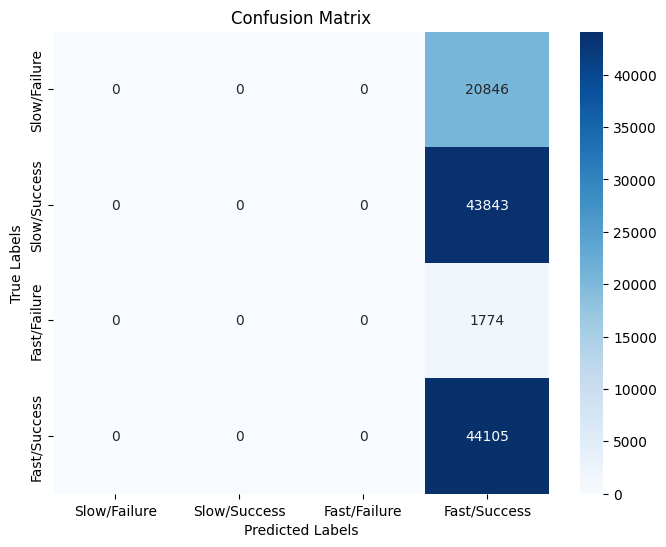

F1 Score for each class: [0.         0.         0.         0.57029992]
Macro-average F1 Score: 0.1425749807658738
Micro-average F1 Score: 0.3988947977715071
Weighted-average F1 Score: 0.227489672479519


In [44]:
from sklearn.metrics import f1_score
CLIST =  ["Slow/Failure", "Slow/Success", "Fast/Failure", "Fast/Success"]
y_from_network = []
y = []
for vv, tsts in zip(vc, TSve):
    # print(vv, tsts)
    # break
# pdb.set_trace()
    for v in vv:
        y_from_network.append(v.tolist())
    y+=tsts[0].tolist()     
# pdb.set_trace()

y_pred_indices = np.argmax(y_from_network, axis=1)
cm = confusion_matrix(y, y_pred_indices)
# for y_ in y_from_network(v.)
# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
f1_each_class = f1_score(y, y_pred_indices, average=None)
print("F1 Score for each class:", f1_each_class)

# Calculate macro-average F1 score (unweighted average across all classes)
f1_macro = f1_score(y, y_pred_indices, average='macro')
print("Macro-average F1 Score:", f1_macro)

# Calculate micro-average F1 score (weighted by support, considers overall precision and recall)
f1_micro = f1_score(y, y_pred_indices, average='micro')
print("Micro-average F1 Score:", f1_micro)

# Calculate weighted-average F1 score (weighted by the number of true instances for each class)
f1_weighted = f1_score(y, y_pred_indices, average='weighted')
print("Weighted-average F1 Score:", f1_weighted)
# trainX = []
# trainy = []
# for vv, tsts in zip(embed, tsclass):
#     # print(vv, tsts)
#     # break
# # pdb.set_trace()
#     for v in vv:
#         trainX.append(v.tolist())
#     try:
#         trainy+=tsts.tolist()  
#     except Exception as e:
#         print(e)
#         pdb.set_trace()

In [33]:
CLIST =  ["Slow/Failure", "Slow/Success", "Fast/Failure", "Fast/Success"]
X = []
y = []
for vv, tsts in zip(ve, TSve):
    # print(vv, tsts)
    # break
# pdb.set_trace()
    for v in vv:
        X.append(v.tolist())
    y+=tsts[0].tolist()     
# pdb.set_trace()

trainX = []
trainy = []
for vv, tsts in zip(embed, tsclass):
    # print(vv, tsts)
    # break
# pdb.set_trace()
    for v in vv:
        trainX.append(v.tolist())
    try:
        trainy+=tsts.tolist()  
    except Exception as e:
        print(e)
        pdb.set_trace()

In [35]:

colorlist = ['#e41a1c', '#984ea3', '#377eb8', '#4daf4a']#, '#ff7f00', '#ffff33', '#a65628']
alphalist = [0.3, 0.7, 1.0, 0.3]
alphalist = [0.3, 0.3, 0.3, 0.3]
sizelist = [5, 10, 20, 5]
sizelist = [5, 5, 5, 5]


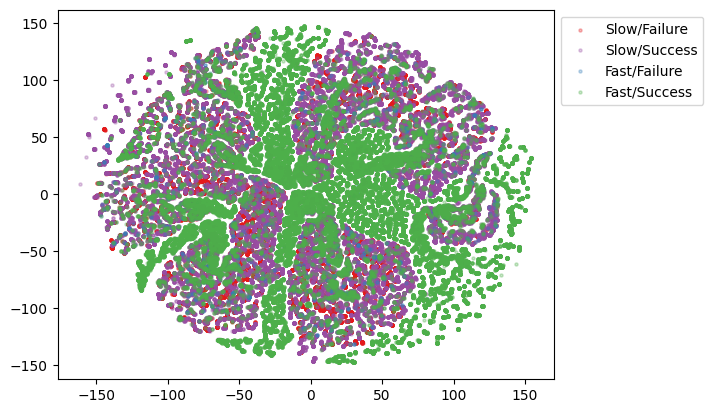

In [36]:
toplotEmbeds = []
yplot = []
for vv, tsts in zip(ve, TSve):
    # pdb.set_trace()
    for v in vv:
        toplotEmbeds.append(v.tolist())
    yplot+=tsts[0].tolist()     
z_test = TSNE(n_components=2).fit_transform(np.array(toplotEmbeds))

def extract_nodes_by_class(data,class_number):
    index_list = []
    # pdb.set_trace()
    for index, item in enumerate(data):
        if data[index] == class_number:
            index_list.append(index)
    return index_list

# fig = plt.figure()
# ax = fig.add_subplot(projection='2d')
#  z_test[index_list,2],
for class_number in range(4):
    index_list = extract_nodes_by_class(yplot, class_number)
    plt.scatter(z_test[index_list,0], z_test[index_list,1], s=sizelist[class_number], c=colorlist[class_number], alpha = alphalist[class_number])

plt.legend(CLIST,bbox_to_anchor=(1, 1), loc='upper left')

In [21]:
# np.sum([1 for y in yplot[1] if y==1])

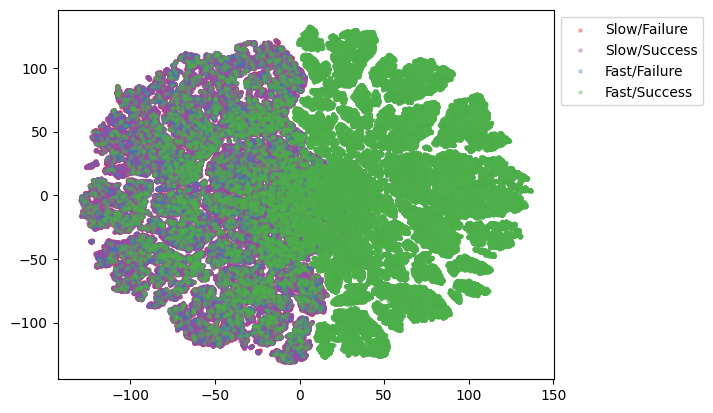

In [22]:
toplotEmbeds = []
yplot = []
for vv, tsts in zip(embed, tsclass):
# pdb.set_trace()
    for v in vv:
        toplotEmbeds.append(v.tolist())
    yplot+=tsts.tolist()     
z = TSNE(n_components=2).fit_transform(np.array(toplotEmbeds))

def extract_nodes_by_class(data,class_number):
    index_list = []
    # pdb.set_trace()
    for index, item in enumerate(data):
        if data[index] == class_number:
            index_list.append(index)
    return index_list

# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')

for class_number in range(4):
    index_list = extract_nodes_by_class(yplot, class_number)
    plt.scatter(z[index_list,0], z[index_list,1], s=sizelist[class_number], c=colorlist[class_number], alpha = alphalist[class_number])

plt.legend(CLIST,bbox_to_anchor=(1, 1), loc='upper left')

In [23]:
for class_number in range(4):
    index_list = extract_nodes_by_class(trainy, class_number)
    print(len(index_list))

57031
109713
5261
136524


In [24]:
est = GradientBoostingClassifier(n_estimators=200, max_depth=3)#, min_samples_split=5) # n_estimators is the number of trees and max_depth is the maximum depth of any individual tree.
est.fit(trainX, trainy)


KeyboardInterrupt: 

F1 Score for each class: [0.05680927 0.42240729 0.49066293 0.58075505]
Macro-average F1 Score: 0.3876586370249221
Micro-average F1 Score: 0.46807628328675976
Weighted-average F1 Score: 0.40591109064693903


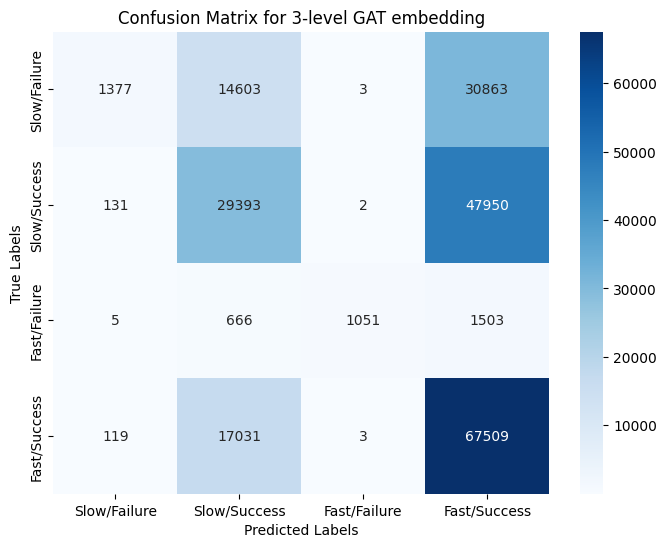

In [ ]:

y_pred_TRAIN = est.predict(trainX)
cm = confusion_matrix(trainy, y_pred_TRAIN)#, labels = bin_dict.values())
# CLIST =  bin_dict.values()
# y_pred_TRAIN = est.predict(X)
# cm = confusion_matrix(trainy, y_pred_TRAIN)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for 3-level GAT embedding')

f1_each_class = f1_score(trainy, y_pred_TRAIN, average=None)
print("F1 Score for each class:", f1_each_class)

# Calculate macro-average F1 score (unweighted average across all classes)
f1_macro = f1_score(trainy, y_pred_TRAIN, average='macro')
print("Macro-average F1 Score:", f1_macro)

# Calculate micro-average F1 score (weighted by support, considers overall precision and recall)
f1_micro = f1_score(trainy, y_pred_TRAIN, average='micro')
print("Micro-average F1 Score:", f1_micro)

# Calculate weighted-average F1 score (weighted by the number of true instances for each class)
f1_weighted = f1_score(trainy, y_pred_TRAIN, average='weighted')
print("Weighted-average F1 Score:", f1_weighted)

F1 Score for each class: [0.0087598  0.11488643 0.00571429 0.50336522]
Macro-average F1 Score: 0.15818143319334727
Micro-average F1 Score: 0.3479120690149322
Weighted-average F1 Score: 0.2182337338374598


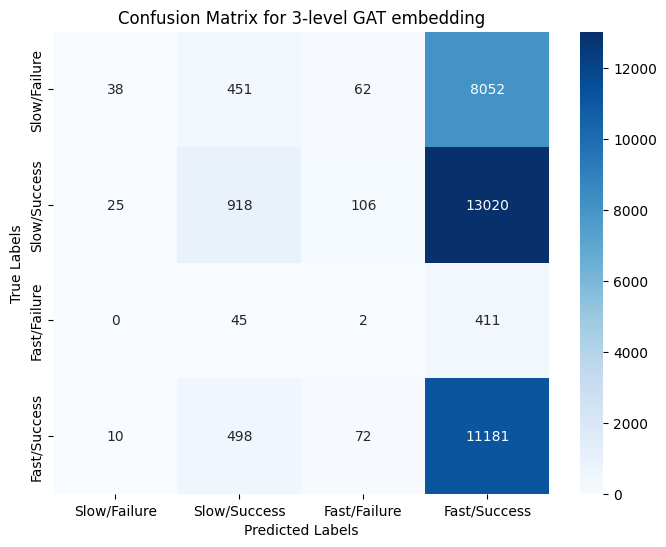

In [ ]:

y_pred = est.predict(X)
cm = confusion_matrix(y, y_pred)#, labels = bin_dict.values())
# CLIST =  bin_dict.values()
# y_pred = est.predict(X)
# cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for 3-level GAT embedding')
from sklearn.metrics import f1_score
f1_each_class = f1_score(y, y_pred, average=None)
print("F1 Score for each class:", f1_each_class)

# Calculate macro-average F1 score (unweighted average across all classes)
f1_macro = f1_score(y, y_pred, average='macro')
print("Macro-average F1 Score:", f1_macro)

# Calculate micro-average F1 score (weighted by support, considers overall precision and recall)
f1_micro = f1_score(y, y_pred, average='micro')
print("Micro-average F1 Score:", f1_micro)

# Calculate weighted-average F1 score (weighted by the number of true instances for each class)
f1_weighted = f1_score(y, y_pred, average='weighted')
print("Weighted-average F1 Score:", f1_weighted)

In [ ]:

# y_pred = est.predict(X)
# cm = confusion_matrix(y, y_pred)#, labels = bin_dict.values())
# # CLIST =  bin_dict.values()
# # y_pred = est.predict(X)
# # cm = confusion_matrix(y, y_pred)

# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.title('Confusion Matrix for 3-level GAT embedding')
# from sklearn.metrics import f1_score
# f1_each_class = f1_score(y, y_pred, average=None)
# print("F1 Score for each class:", f1_each_class)

# # Calculate macro-average F1 score (unweighted average across all classes)
# f1_macro = f1_score(y, y_pred, average='macro')
# print("Macro-average F1 Score:", f1_macro)

# # Calculate micro-average F1 score (weighted by support, considers overall precision and recall)
# f1_micro = f1_score(y, y_pred, average='micro')
# print("Micro-average F1 Score:", f1_micro)

# # Calculate weighted-average F1 score (weighted by the number of true instances for each class)
# f1_weighted = f1_score(y, y_pred, average='weighted')
# print("Weighted-average F1 Score:", f1_weighted)

multii graph--TIME_LIMIT = 400
SUCC_LIMIT = 0.9
ne = 5, d = 6 
F1 Score for each class: [0.84543167 0.01915403 0.         0.84812481]
Macro-average F1 Score: 0.42817762933744735
Micro-average F1 Score: 0.7546111530579226
Weighted-average F1 Score: 0.6682228916229003

single graph-- TIME_LIMIT = 400
SUCC_LIMIT = 0.8
F1 Score for each class: [0.63074141 0.52451434 0.         0.96412556]
Macro-average F1 Score: 0.5298453274004389
Micro-average F1 Score: 0.6603295310519645
Weighted-average F1 Score: 0.6625507969714359


